# Regional Logistics Transfers – Delay Prediction

**Group #15**

The task is a binary classification problem: predict whether a transfer arrives **more than 30 minutes late** relative to its scheduled arrival time (`is_delayed`).

Part 1: Exploration

Features to Check: Geo Location, vendors, departure hours, date, correlation between departure delays and arrival delays, route length, types of delays, impact of anonymouse features, redundent features

#TODO
האם קיימים הבדלים משמעותיים ברמת העיכובים בין אזורים גיאוגרפיים שונים או בין ספקי לוגיסטיקה שונים ?
• האם שעות יציאה מסוימות במהלך היום מאופיינות בהסתברות גבוהה יותר לעיכובים ?
• האם קיים קשר בין עיכובי יציאה לבין עיכובי הגעה? עד כמה עיכוב ביציאה משפיע על הסיכוי לעיכוב משמעותי
בהגעה?
• האם מרחק המסלול המתוכנן משפיע על רמת העיכובים?
• האם קיימים קשרים קורלטיביים חזקים בין סוגי העיכובים השונים?
• האם קיימים מסבירים אנונימיים אשר נראים כבעלי השפעה משמעותית על משתנה המטרה
• האם קיימים פיצ'רים אשר נראים לא רלוונטיים או בעלי תרומה נמוכה במיוחד לחיזוי?

## Setup

We import the standard data-science stack used in class (`pandas`, `numpy`, `matplotlib`, `seaborn`) and fix a plotting style and random seed for reproducibility.

In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
TARGET = "is_delayed"

## Phase 1 – Data Sanity & Initial Profiling

We load the training set and take a first look at its shape, data types, summary statistics, number of unique values per column and missing values. The goal is to understand what each column represents, spot irrelevant columns, and get an early sense of distributions and potential outliers.

In [11]:
# Load the training data.
TRAIN_PATH = "regional_logistics_transfers_train.csv"

df = pd.read_csv(TRAIN_PATH)
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (51056, 23)


,operation_date,day_of_week,scheduled_dispatch_time,expected_dispatch_delay_minutes,scheduled_arrival_time,source_facility,source_region,destination_facility,destination_region,logistics_provider,...,expected_weather_disruption_minutes,expected_network_congestion_delay_minutes,expected_inspection_delay_minutes,expected_previous_transfer_delay_minutes,internal_metric_a,internal_metric_b,internal_timestamp_a,internal_timestamp_b,internal_operational_score,is_delayed
0,2024-04-01,1,830,2.0,1217,FACILITY_298,REGION_005,FACILITY_091,REGION_006,UA,...,0.0,0.0,0.0,0,NaN,4.0,900.0,1202.0,52.542136,0
1,2024-04-01,1,1500,-7.0,1642,FACILITY_112,REGION_029,FACILITY_273,REGION_032,9E,...,0.0,0.0,0.0,0,14.0,4.0,1451.0,1616.0,58.169563,0
2,2024-04-01,1,1340,-3.0,1522,FACILITY_273,REGION_032,FACILITY_174,REGION_031,9E,...,0.0,0.0,0.0,0,16.0,5.0,1342.0,1537.0,57.702196,0
3,2024-04-01,1,1325,-11.0,1501,FACILITY_159,REGION_048,FACILITY_099,REGION_021,9E,...,NaN,NaN,0.0,0,14.0,6.0,1220.0,1427.0,51.548966,0
4,2024-04-01,1,1012,-5.0,1200,FACILITY_099,REGION_021,FACILITY_174,REGION_031,9E,...,0.0,0.0,0.0,0,23.0,NaN,1055.0,1202.0,61.802930,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51056 entries, 0 to 51055
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   operation_date                             51056 non-null  object 
 1   day_of_week                                51056 non-null  int64  
 2   scheduled_dispatch_time                    51056 non-null  int64  
 3   expected_dispatch_delay_minutes            50435 non-null  float64
 4   scheduled_arrival_time                     51056 non-null  int64  
 5   source_facility                            51056 non-null  object 
 6   source_region                              51056 non-null  object 
 7   destination_facility                       51056 non-null  object 
 8   destination_region                         51056 non-null  object 
 9   logistics_provider                         51056 non-null  object 
 10  scheduled_travel_time_

In [13]:
# Summary statistics for the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day_of_week,51056.0,3.976614,1.997433,1.000000,2.000000,4.000000,6.00000,7.000000
scheduled_dispatch_time,51056.0,1312.670538,390.114446,700.000000,951.000000,1317.000000,1650.00000,1959.000000
expected_dispatch_delay_minutes,50435.0,15.702786,58.350467,-22.000000,-5.000000,-1.000000,12.00000,2120.000000
scheduled_arrival_time,51056.0,1573.085396,422.308204,1.000000,1230.000000,1608.000000,1925.00000,2359.000000
scheduled_travel_time_minutes,51056.0,184.786607,85.959995,55.000000,122.000000,167.000000,221.00000,764.000000
route_distance_miles,51056.0,1181.731808,769.964405,92.000000,663.600000,1033.800000,1498.40000,14341.700000
expected_provider_delay_minutes,47480.0,5.132603,36.426832,0.000000,0.000000,0.000000,0.00000,2053.000000
expected_weather_disruption_minutes,45952.0,0.572380,12.246334,0.000000,0.000000,0.000000,0.00000,1052.000000
expected_network_congestion_delay_minutes,46966.0,4.295192,22.486952,0.000000,0.000000,0.000000,0.00000,1080.000000
expected_inspection_delay_minutes,44933.0,0.022166,0.997570,0.000000,0.000000,0.000000,0.00000,94.000000


In [14]:
# Number of unique values per column
# Helps to explore the data and understand the different values each feature can take.
df.nunique().sort_values()

is_delayed                                       2
operation_date                                   7
day_of_week                                      7
logistics_provider                              28
expected_inspection_delay_minutes               33
source_facility                                 40
destination_facility                            40
source_region                                   47
destination_region                              48
internal_metric_b                               89
internal_metric_a                              136
expected_weather_disruption_minutes            147
expected_network_congestion_delay_minutes      294
expected_provider_delay_minutes                320
expected_previous_transfer_delay_minutes       371
scheduled_travel_time_minutes                  398
expected_dispatch_delay_minutes                517
scheduled_dispatch_time                        780
scheduled_arrival_time                        1020
route_distance_miles           

In [15]:
# Missing values per feature, as a count and as a percentage of all rows
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
internal_metric_a,8320,16.30
expected_inspection_delay_minutes,6123,11.99
internal_metric_b,5782,11.32
expected_weather_disruption_minutes,5104,10.00
expected_network_congestion_delay_minutes,4090,8.01
expected_provider_delay_minutes,3576,7.00
internal_timestamp_b,680,1.33
internal_timestamp_a,669,1.31
expected_dispatch_delay_minutes,621,1.22


In [16]:
# Group the columns by role – this is reused throughout the exploration.
delay_cols = [
    "expected_dispatch_delay_minutes",
    "expected_provider_delay_minutes",
    "expected_weather_disruption_minutes",
    "expected_network_congestion_delay_minutes",
    "expected_inspection_delay_minutes",
    "expected_previous_transfer_delay_minutes",
]
route_cols = ["scheduled_travel_time_minutes", "route_distance_miles"]
anon_cols = [
    "internal_metric_a",
    "internal_metric_b",
    "internal_timestamp_a",
    "internal_timestamp_b",
    "internal_operational_score",
]
categorical_cols = [
    "source_region",
    "destination_region",
    "source_facility",
    "destination_facility",
    "logistics_provider",
    "day_of_week",
]
print("Delay columns:", len(delay_cols), "| Route:", len(route_cols), "| Anonymous:", len(anon_cols))

Delay columns: 6 | Route: 2 | Anonymous: 5


## Univariate Distribution Analysis

We look at one variable at a time: the balance of the target, the distribution of the continuous features (route, delays, anonymous metrics) and the frequency of the main categorical fields. This tells us which features are roughly symmetric, which are heavy-tailed, and where outliers live.

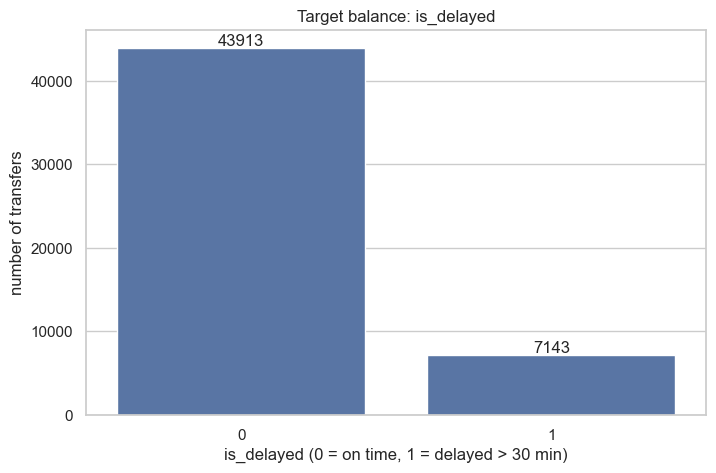

is_delayed
0    0.8601
1    0.1399
Name: proportion, dtype: float64


In [17]:
# Target balance
ax = sns.countplot(data=df, x=TARGET)
ax.set_title("Target balance: is_delayed")
ax.set_xlabel("is_delayed (0 = on time, 1 = delayed > 30 min)")
ax.set_ylabel("number of transfers")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

print(df[TARGET].value_counts(normalize=True).round(4))

/opt/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


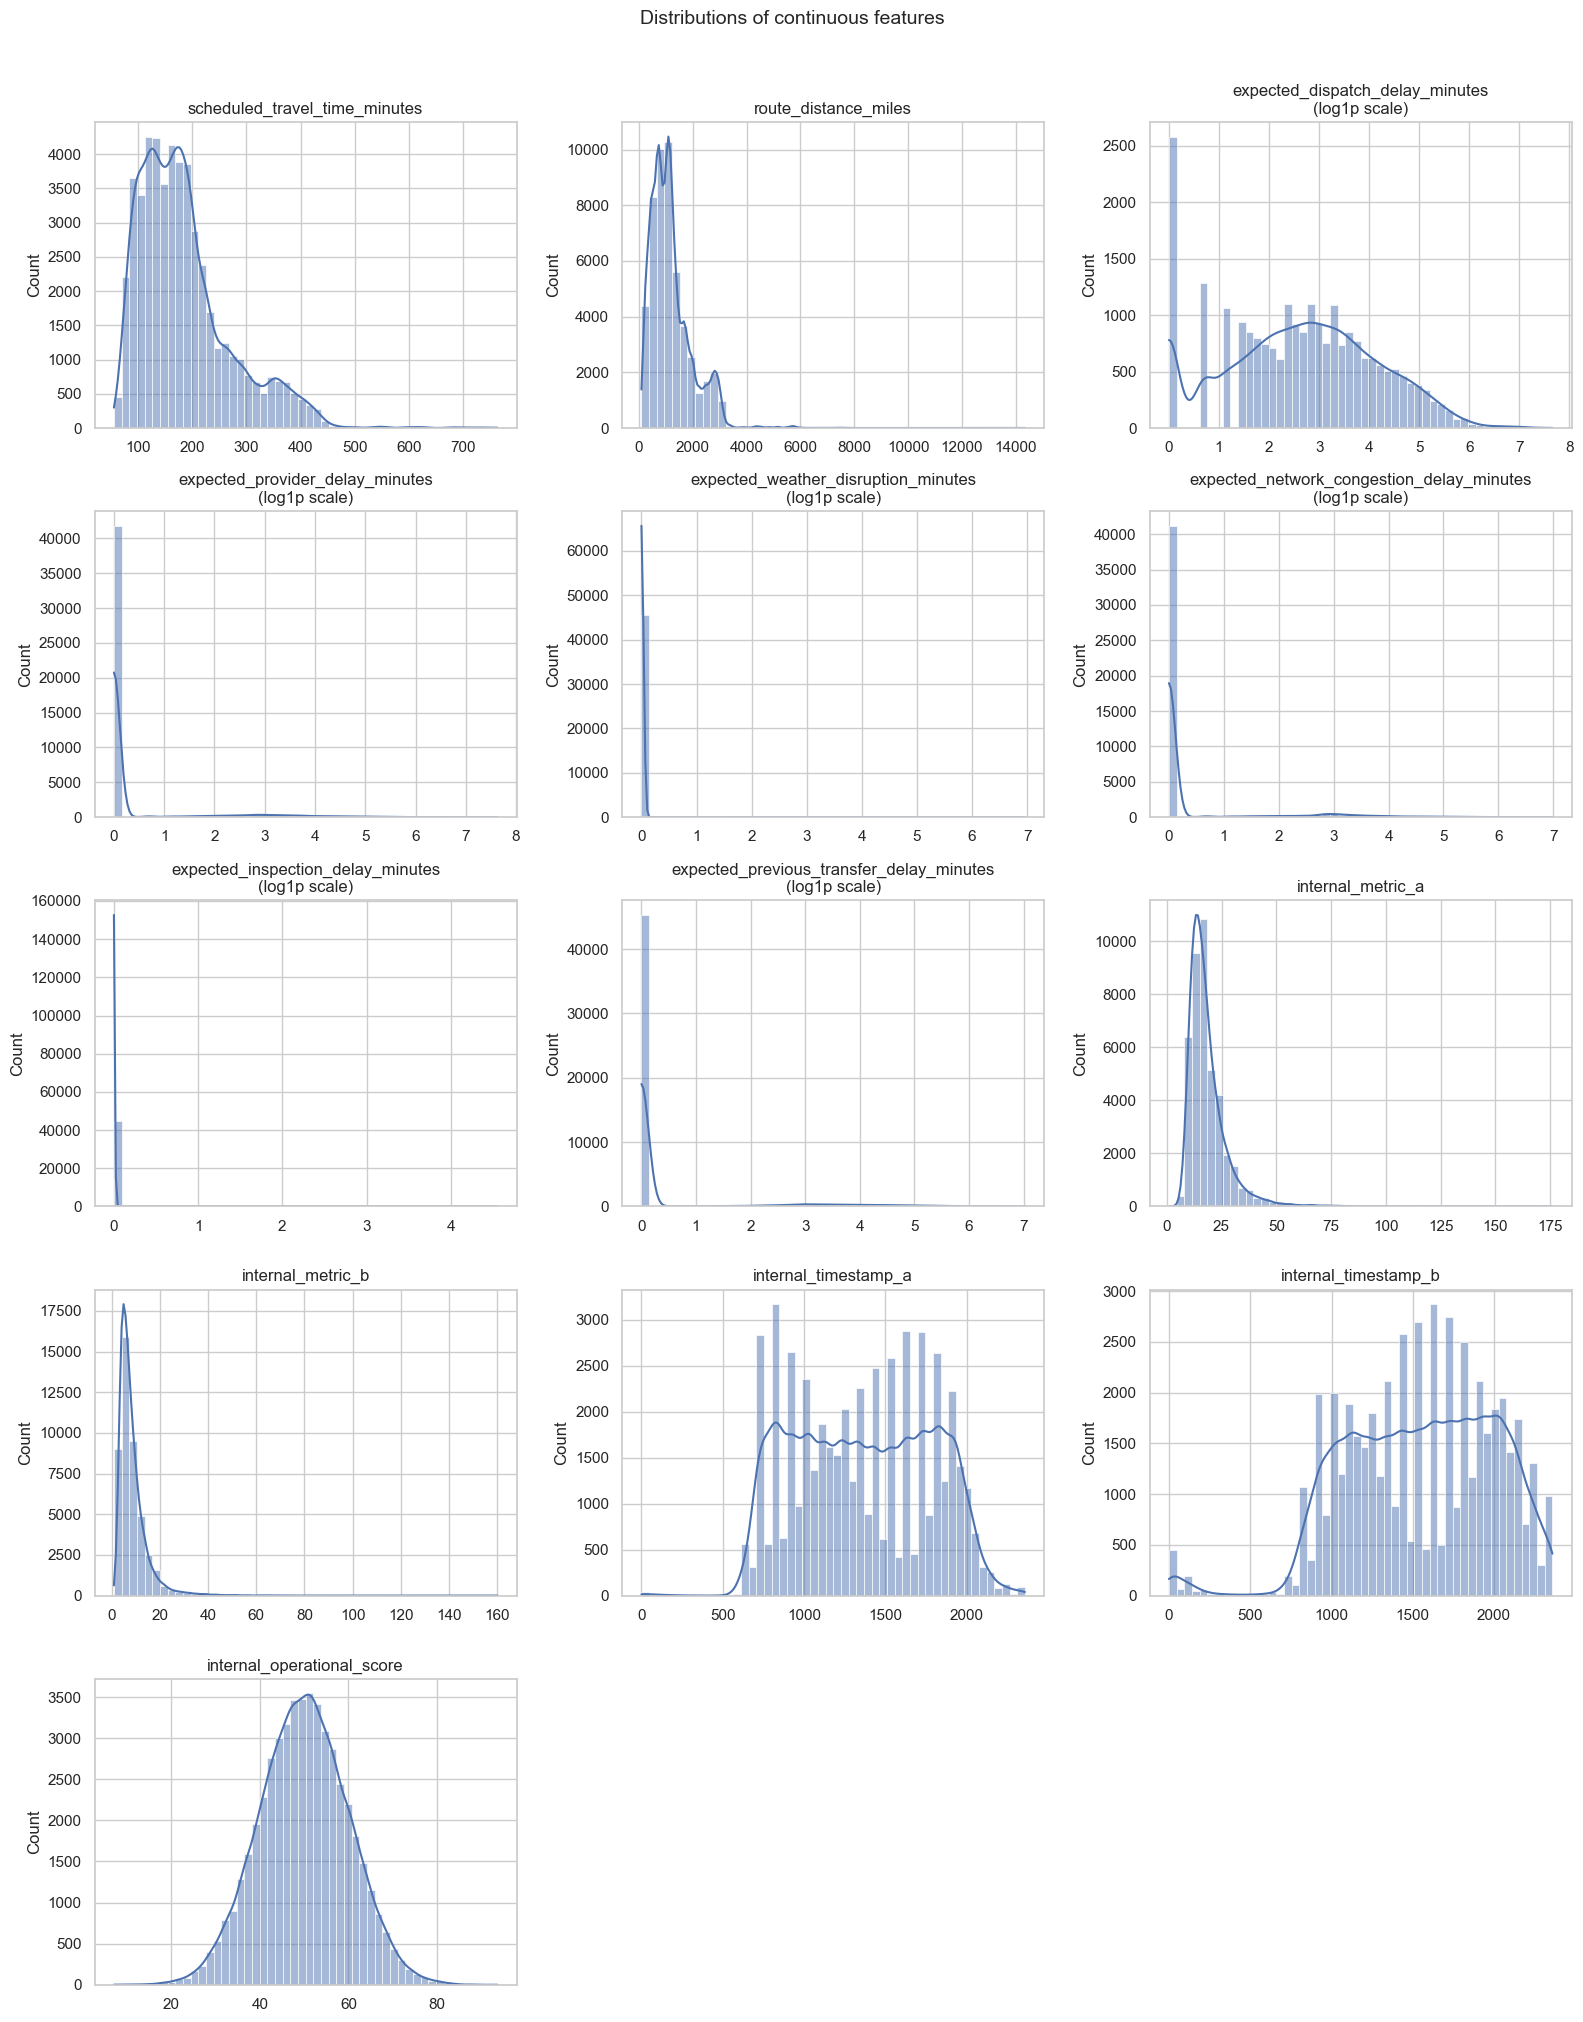

In [18]:
# GOOVER
# Histograms of the continuous features (route, expected delays, anonymous metrics)
# Expected-delay columns are zero-inflated and right-skewed -> log1p scale for those
continuous_cols = route_cols + delay_cols + anon_cols

n_cols = 3
n_rows = int(np.ceil(len(continuous_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    data = df[col].dropna()
    if col in delay_cols:
        # Shift by 1 to handle zeros, then take log
        sns.histplot(np.log1p(data), bins=50, kde=True, ax=ax)
        ax.set_title(f"{col}\n(log1p scale)")
    else:
        sns.histplot(data, bins=50, kde=True, ax=ax)
        ax.set_title(col)
    ax.set_xlabel("")

# Hide any unused subplot
for ax in axes[len(continuous_cols):]:
    ax.set_visible(False)

fig.suptitle("Distributions of continuous features", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()


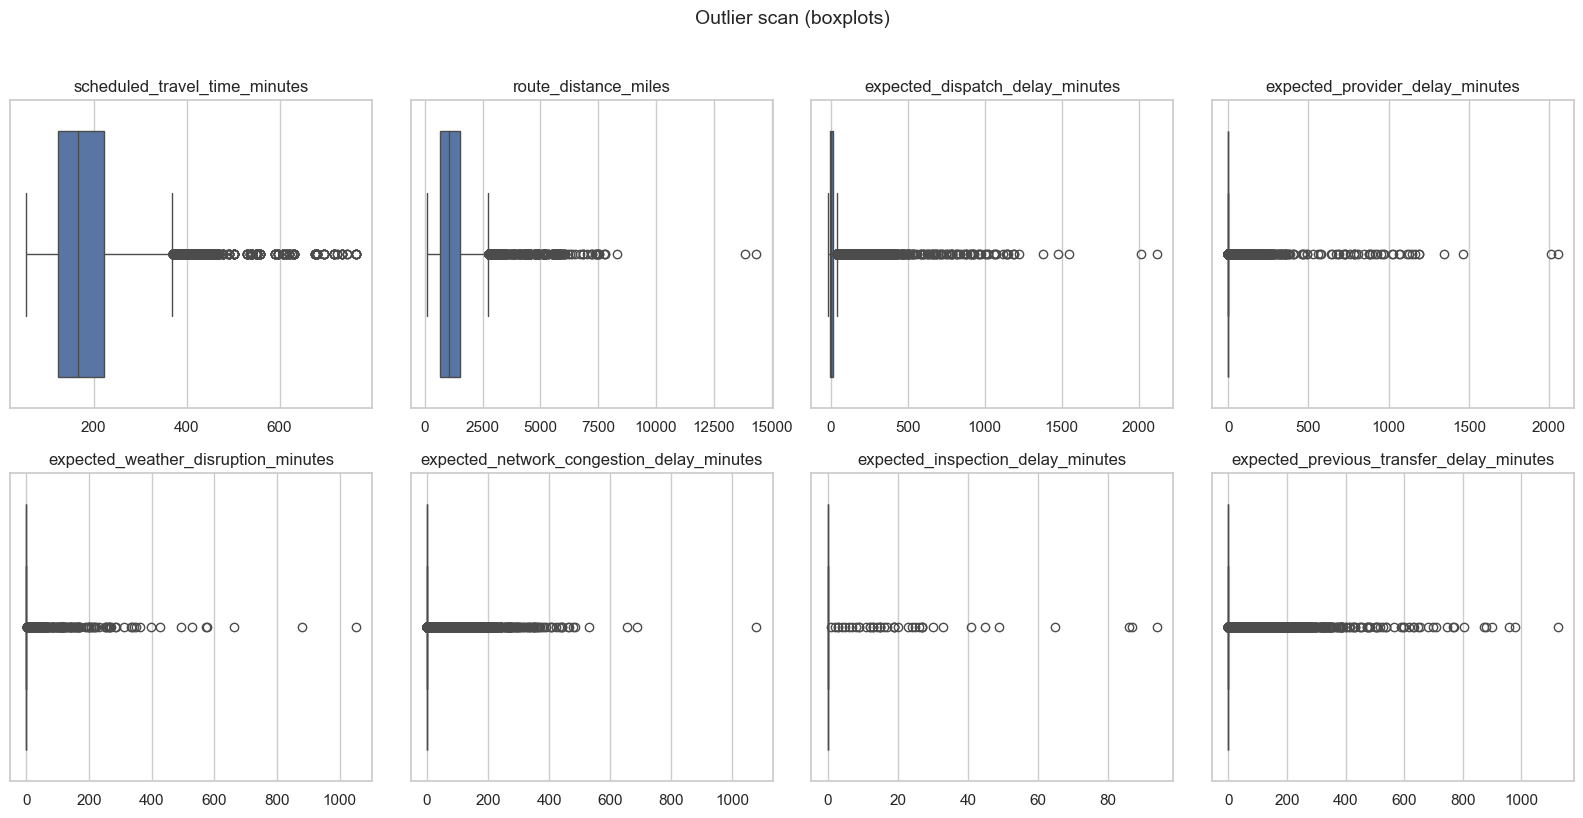

In [19]:
# Boxplots to make the outliers in the route and delay features explicit and proven
box_cols = route_cols + delay_cols

n_cols = 4
n_rows = int(np.ceil(len(box_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, box_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(box_cols):]:
    ax.set_visible(False)

fig.suptitle("Outlier scan (boxplots)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

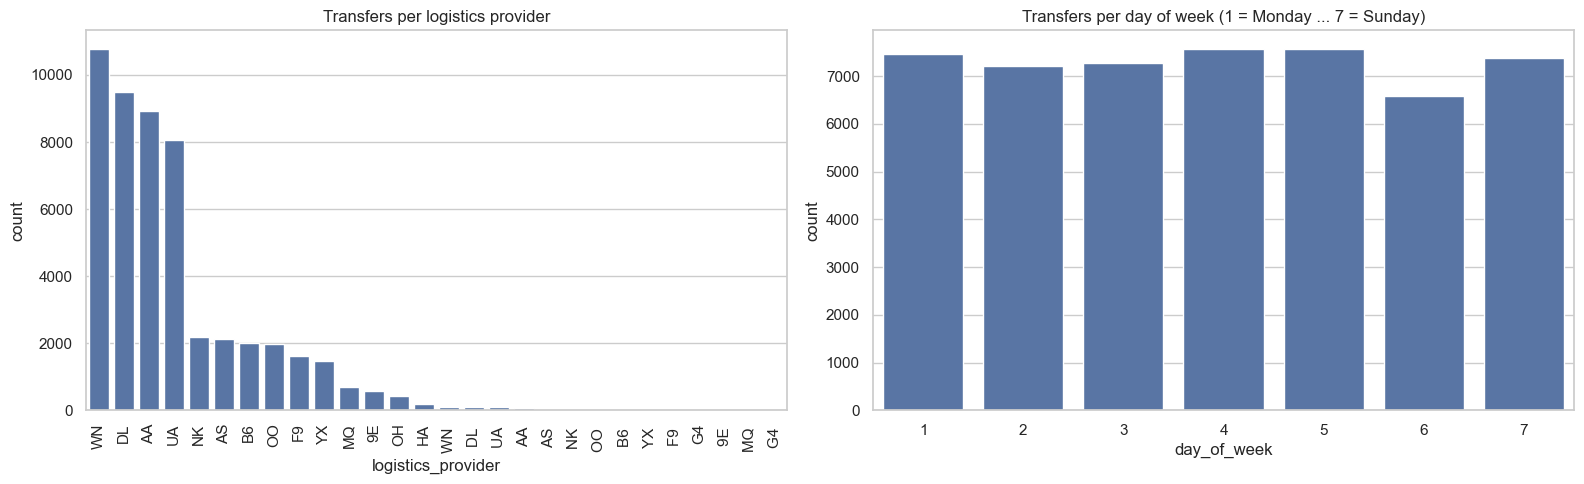

In [20]:
# Frequency of the two main categorical features
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = df["logistics_provider"].value_counts().index
sns.countplot(data=df, x="logistics_provider", order=order, ax=axes[0])
axes[0].set_title("Transfers per logistics provider")
axes[0].tick_params(axis="x", rotation=90)

sns.countplot(data=df, x="day_of_week", ax=axes[1])
axes[1].set_title("Transfers per day of week (1 = Monday ... 7 = Sunday)")

fig.tight_layout()
plt.show()

### Conclusions

- **Target imbalance.** Confirmed visually: 43,913 on-time vs. 7,143 delayed (~14% positive class). Models and evaluation should account for this (AUC, class weights / resampling).
- **Roughly normal feature.** `internal_operational_score` is clearly bell-shaped around 50 with std ~10 – the only feature that looks approximately Gaussian.
- **Heavy-tailed / skewed features.** `route_distance_miles`, `scheduled_travel_time_minutes`, `internal_metric_a` and `internal_metric_b` are right-skewed with a long tail (a Chi-square-like shape). The six expected-delay columns are **zero-inflated**: the vast majority of values are exactly 0 with a small fraction of very large delays. These will likely benefit from a log/robust transform and outlier handling later.
- **Anonymous timestamps.** `internal_timestamp_a` and `internal_timestamp_b` span 0–2359 and are concentrated in daytime hours – they behave like `HHMM` clock times rather than opaque metrics, with a small spike near 0 (likely midnight or a placeholder).
- **Outliers.** The boxplots show many extreme high values in every delay column and in `route_distance_miles` (a few routes above 8,000–14,000 miles). We will decide how to treat these in the preprocessing phase rather than discard them now.
- **Categoricals.** Transfers are spread fairly evenly across the 7 days of the week (slightly fewer on day 6). The provider field is dominated by four carriers (WN, DL, AA, UA). **Data-quality issue found:** `logistics_provider` has trailing-whitespace duplicates (e.g. `'9E '` vs `'9E'`), which split 14 real codes into 28 categories. This must be stripped/normalised in preprocessing.

## Bivariate & Multivariate Analysis

In this phase we answer the assignment's exploration questions one by one. For each question we compute the relevant statistic, plot it, and write the conclusion in a Markdown cell directly below.

Because we will repeatedly group categorical text fields, we first apply a **minimal text cleanup** (strip surrounding whitespace) so that the trailing-space duplicates found above do not split groups. This is the only cleaning done in the exploration phase; full preprocessing happens in Part 2.

In [21]:
# Minimal text cleanup so grouping is not distorted by trailing whitespace
text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].apply(lambda s: s.str.strip())

print("logistics_provider categories after cleanup:", df["logistics_provider"].nunique())

logistics_provider categories after cleanup: 15


### GOOVER Q1: Differences in delay level between regions and between logistics providers

We measure the **delay rate** (the mean of `is_delayed`) for each logistics provider and for each source / destination region. The overall delay rate (~14%) is the baseline; we look for groups that deviate strongly from it. We only show regions with a reasonable number of transfers so the rates are not driven by tiny samples.

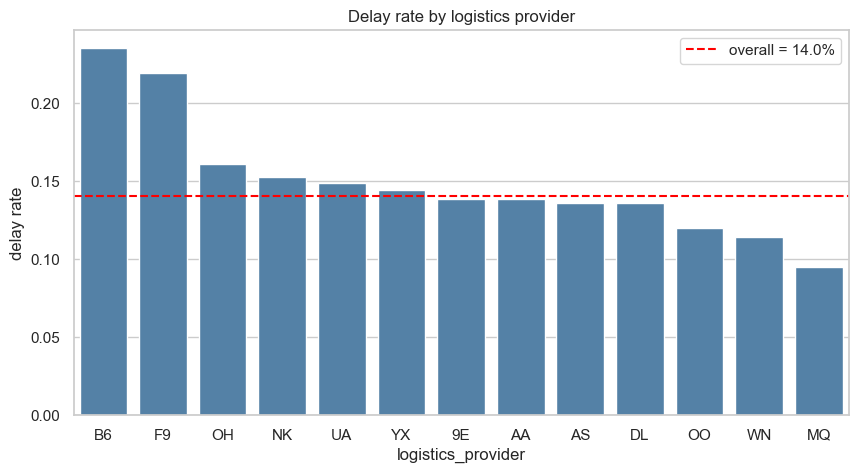

,delay_rate,n
logistics_provider,,
B6,0.235,2015
F9,0.219,1635
OH,0.160,424
NK,0.152,2213
UA,0.148,8145
YX,0.144,1484
9E,0.139,599
AA,0.138,9004
AS,0.136,2138


In [22]:
overall_rate = df[TARGET].mean()


def delay_rate_by(col, min_count=200):
    """Mean delay rate and transfer count per category of `col`, filtered by a
    minimum number of transfers so rates are not driven by tiny groups."""
    g = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    return g[g["n"] >= min_count].sort_values("delay_rate", ascending=False)


# Delay rate per logistics provider
provider_rate = delay_rate_by("logistics_provider", min_count=200)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=provider_rate.reset_index(), x="logistics_provider", y="delay_rate",
                 order=provider_rate.index, color="steelblue")
ax.axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
ax.set_title("Delay rate by logistics provider")
ax.set_ylabel("delay rate")
ax.legend()
plt.show()

provider_rate.round(3)

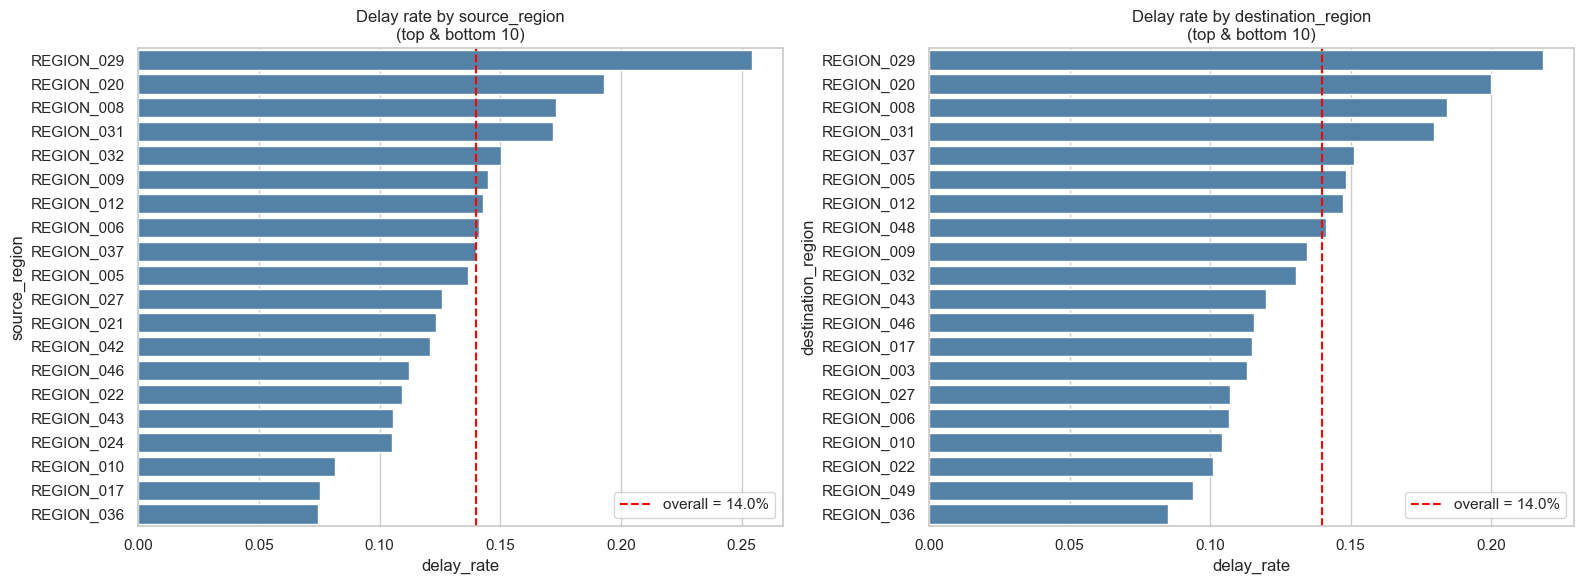

Source region delay rate – spread:  min=7.5%, max=25.4%
Dest region delay rate   – spread:  min=8.5%, max=21.9%


In [23]:
# Delay rate per source and destination region (top and bottom 10 by rate)
source_rate = delay_rate_by("source_region", min_count=200)
dest_rate = delay_rate_by("destination_region", min_count=200)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (rate, name) in zip(axes, [(source_rate, "source_region"), (dest_rate, "destination_region")]):
    extremes = pd.concat([rate.head(10), rate.tail(10)])
    sns.barplot(data=extremes.reset_index(), y=name, x="delay_rate", color="steelblue", ax=ax)
    ax.axvline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
    ax.set_title(f"Delay rate by {name}\n(top & bottom 10)")
    ax.legend()

fig.tight_layout()
plt.show()

print("Source region delay rate – spread:  "
      f"min={source_rate['delay_rate'].min():.1%}, max={source_rate['delay_rate'].max():.1%}")
print("Dest region delay rate   – spread:  "
      f"min={dest_rate['delay_rate'].min():.1%}, max={dest_rate['delay_rate'].max():.1%}")

### Answer 1

**Yes – there are clear differences both between providers and between regions.**

- **Providers:** delay rate ranges from ~9.4% (`MQ`) to ~23.5% (`B6`), against an overall 14%. `B6` and `F9` stand out as roughly **1.5–1.7× the average** delay rate, while large carriers such as `WN`, `DL` and `AA` sit at or slightly below average. The provider therefore carries real signal.
- **Regions:** the source region delay rate spans **7.5%–25.4%** and the destination region **8.5%–21.9%**. `REGION_029` is the worst on both ends (highest as a source *and* as a destination), while `REGION_036` is among the lowest on both. The consistency across source/destination suggests some regions are genuinely congestion-prone.

These differences are large relative to the 14% baseline, so `logistics_provider` and the region fields look like useful predictors and are worth encoding in the modelling phase.

### Q2 – Do certain departure hours have a higher probability of delay?

`scheduled_dispatch_time` is stored as an integer in `HHMM` format, so the hour is the value divided by 100. We extract the dispatch hour and compute the delay rate per hour across the day.

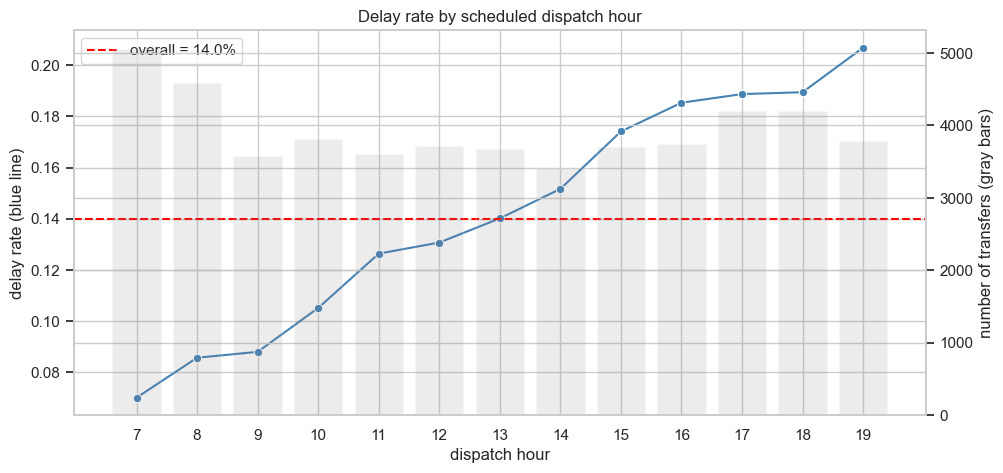

,delay_rate,n
dispatch_hour,,
7,0.070,5060
8,0.086,4583
9,0.088,3578
10,0.105,3813
11,0.126,3608
12,0.131,3718
13,0.140,3675
14,0.152,3409
15,0.174,3694


In [24]:
# Extract the dispatch hour from the HHMM integer and compute the delay rate per hour
df["dispatch_hour"] = df["scheduled_dispatch_time"] // 100

hourly = df.groupby("dispatch_hour")[TARGET].agg(delay_rate="mean", n="count")

fig, ax1 = plt.subplots(figsize=(11, 5))
sns.lineplot(data=hourly.reset_index(), x="dispatch_hour", y="delay_rate",
             marker="o", ax=ax1, color="steelblue")
ax1.axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
ax1.set_title("Delay rate by scheduled dispatch hour")
ax1.set_xlabel("dispatch hour")
ax1.set_ylabel("delay rate (blue line)")
ax1.set_xticks(hourly.index)
ax1.legend(loc="upper left")

# Number of transfers per hour for context
ax2 = ax1.twinx()
ax2.bar(hourly.index, hourly["n"], alpha=0.15, color="gray")
ax2.set_ylabel("number of transfers (gray bars)")
plt.show()

hourly.round(3)

### Answer 2

**Yes – the departure hour has a strong, almost monotonic effect.** All transfers are dispatched between 07:00 and 19:00. The delay rate rises steadily through the day: from only **~7%** for 07:00 departures to **~21%** for 19:00 departures – roughly a **3× difference**. The bars confirm that every hour has thousands of transfers, so the trend is not a small-sample artefact.

This matches the intuition that delays accumulate during the day (a transfer leaving late in the day is more exposed to earlier congestion and knock-on delays). `dispatch_hour` is clearly a valuable engineered feature for the model.

### Q3 – Relationship between departure delay and arrival delay

The dataset's arrival-delay information is the target itself: `is_delayed` marks transfers that arrived more than 30 minutes late. The departure-delay signal is `expected_dispatch_delay_minutes` (negative = dispatched early). We therefore study how the **departure delay** relates to the **probability of a significant arrival delay** (`is_delayed = 1`).

We use a boxplot of the departure delay split by the target, and a conditional-probability table where we bin the departure delay into ranges.

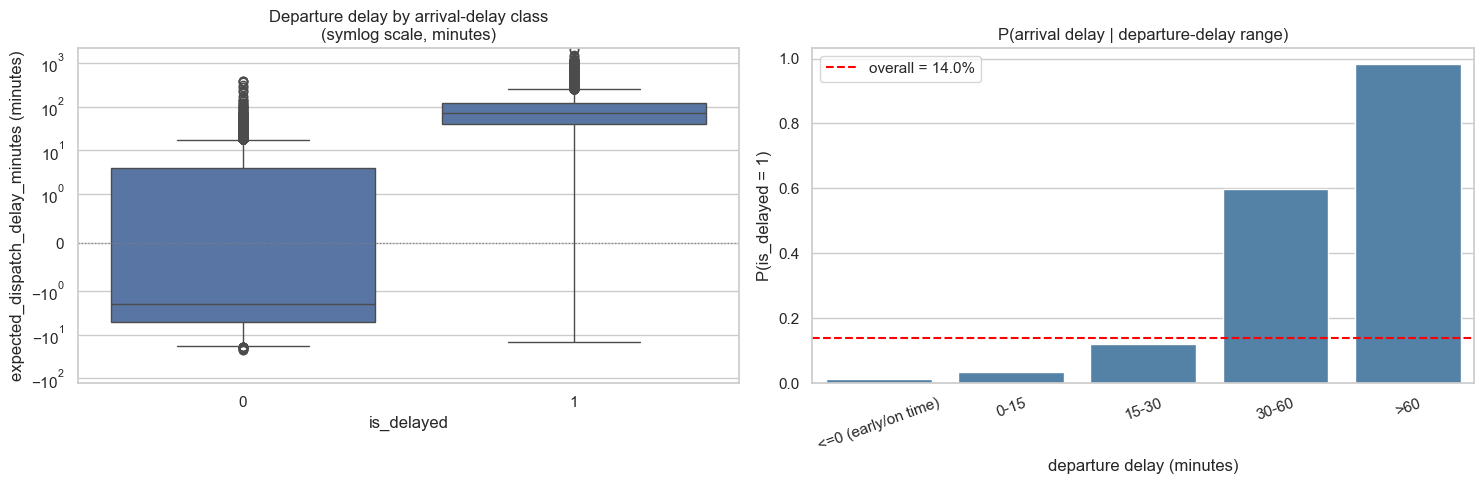

,p_arrival_delay,n
dispatch_delay_bin,,
<=0 (early/on time),0.012,29000
0-15,0.034,10280
15-30,0.121,3844
30-60,0.599,3155
>60,0.984,4156


In [27]:

# Departure delay distribution split by the arrival-delay target.
# Symlog scale: linear around 0 (|x| < 1 min) and logarithmic in both tails.
# This preserves negative values (early dispatch) and handles the heavy right tail
# without clipping or transforming the raw minute values.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x=TARGET, y="expected_dispatch_delay_minutes", ax=axes[0])
axes[0].set_yscale("symlog", linthresh=1)
axes[0].axhline(0, color="gray", linestyle=":", linewidth=0.9)
axes[0].set_title("Departure delay by arrival-delay class\n(symlog scale, minutes)")
axes[0].set_xlabel("is_delayed")
axes[0].set_ylabel("expected_dispatch_delay_minutes (minutes)")

# Conditional probability of a significant arrival delay given a departure-delay range
bins = [-np.inf, 0, 15, 30, 60, np.inf]
labels = ["<=0 (early/on time)", "0-15", "15-30", "30-60", ">60"]
df["dispatch_delay_bin"] = pd.cut(df["expected_dispatch_delay_minutes"], bins=bins, labels=labels)

cond_prob = df.groupby("dispatch_delay_bin", observed=True)[TARGET].agg(
    p_arrival_delay="mean", n="count")

sns.barplot(data=cond_prob.reset_index(), x="dispatch_delay_bin", y="p_arrival_delay",
            color="steelblue", ax=axes[1])
axes[1].axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
axes[1].set_title("P(arrival delay | departure-delay range)")
axes[1].set_xlabel("departure delay (minutes)")
axes[1].set_ylabel("P(is_delayed = 1)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

fig.tight_layout()
plt.show()

cond_prob.round(3)


### Answer 3

**Yes – there is a very strong relationship, and departure delay is the single most informative signal we have seen so far.**

- The boxplot shows that on-time transfers (`is_delayed = 0`) cluster around a *negative* departure delay (median ≈ −2 min, i.e. they leave slightly early), whereas delayed transfers have a much higher departure delay (median ≈ 70 min).
- The conditional-probability table makes the propagation explicit:
  - departure ≤ 0 min → only **1.2%** arrive significantly late,
  - 15–30 min → **12%**,
  - 30–60 min → **60%**,
  - \> 60 min → **98%**.

So a departure delay does not guarantee a late arrival until it grows past ~30 minutes, after which the probability of a significant arrival delay rises sharply. This makes intuitive sense (some of the departure delay can be absorbed by slack in the schedule, but large departure delays cannot be recovered). `expected_dispatch_delay_minutes` should be a top predictor.

### GOOVER Q4: Does the planned route distance affect the delay level?

We bin `route_distance_miles` into quantile groups (so each bin holds a similar number of transfers) and compute the delay rate per bin. Quantile binning is robust to the heavy right tail we saw earlier. We add a logistic trend line for the continuous view.

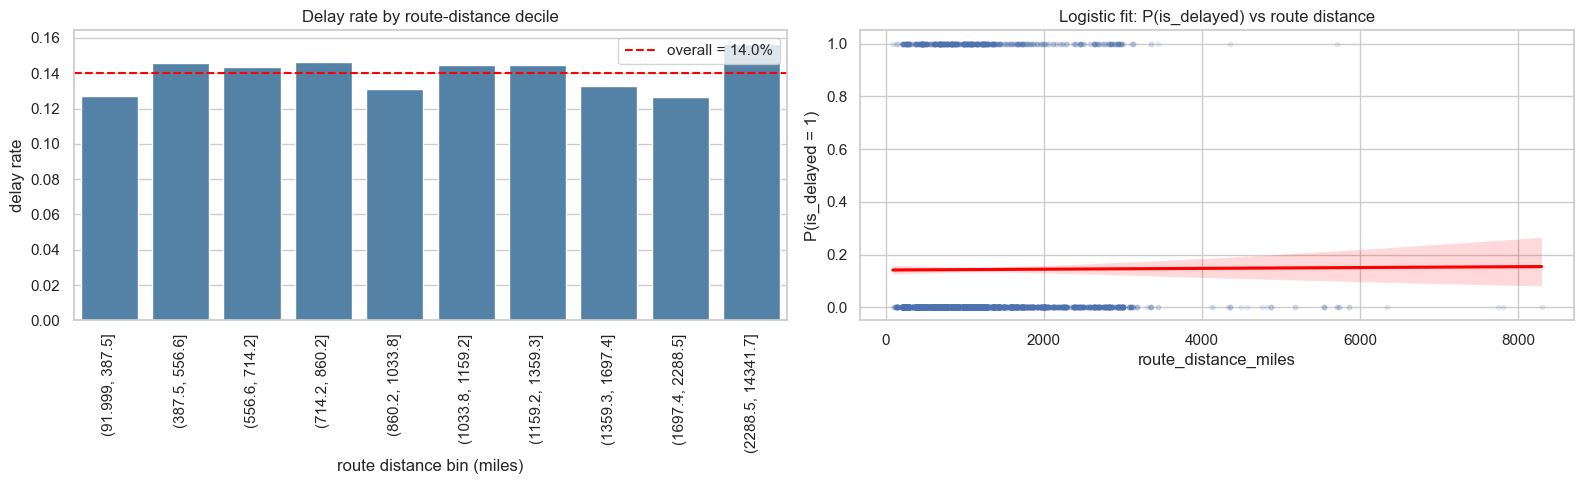

Pearson correlation (route_distance_miles, is_delayed): 0.006


,delay_rate,n
distance_bin,,
"(91.999, 387.5]",0.127,5148
"(387.5, 556.6]",0.146,5094
"(556.6, 714.2]",0.144,5134
"(714.2, 860.2]",0.146,5059
"(860.2, 1033.8]",0.131,5112
"(1033.8, 1159.2]",0.145,5101
"(1159.2, 1359.3]",0.144,5267
"(1359.3, 1697.4]",0.133,4977
"(1697.4, 2288.5]",0.126,5088


In [26]:
# Quantile bins of route distance -> delay rate per bin
df["distance_bin"] = pd.qcut(df["route_distance_miles"], q=10)
dist_rate = df.groupby("distance_bin", observed=True)[TARGET].agg(delay_rate="mean", n="count")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=dist_rate.reset_index(), x="distance_bin", y="delay_rate",
            color="steelblue", ax=axes[0])
axes[0].axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
axes[0].set_title("Delay rate by route-distance decile")
axes[0].set_xlabel("route distance bin (miles)")
axes[0].set_ylabel("delay rate")
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend()

# Logistic trend of delay probability vs distance (sample for speed/clarity)
sample = df.sample(min(5000, len(df)), random_state=RANDOM_STATE)
sns.regplot(data=sample, x="route_distance_miles", y=TARGET, logistic=True,
            scatter_kws={"alpha": 0.1, "s": 10}, line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("Logistic fit: P(is_delayed) vs route distance")
axes[1].set_ylabel("P(is_delayed = 1)")

fig.tight_layout()
plt.show()

# Correlation between raw distance and the target
corr_dist = df["route_distance_miles"].corr(df[TARGET])
print(f"Pearson correlation (route_distance_miles, is_delayed): {corr_dist:.3f}")
dist_rate.round(3)

### Answer 4

**No – the planned route distance has essentially no effect on the delay level.** Across all ten distance deciles the delay rate stays in a narrow **~12.6%–15.6%** band around the 14% baseline, with no monotonic trend. The Pearson correlation between `route_distance_miles` and `is_delayed` is only **0.006**, and the logistic trend line is almost flat. The longest-distance decile is marginally higher (15.6%), but the difference is small compared with the effects of provider, region, departure hour and departure delay.

Conclusion: distance on its own is a weak predictor. It may still contribute in interaction with other features, so we will not drop it outright, but we should not expect much from it.

### Q5 – Strong correlations between the different delay types?

We compute a correlation matrix over the six expected-delay columns plus the target. Because these columns are heavy-tailed and zero-inflated, **Spearman** (rank) correlation is more appropriate than Pearson, so we show Spearman and add Pearson for reference.

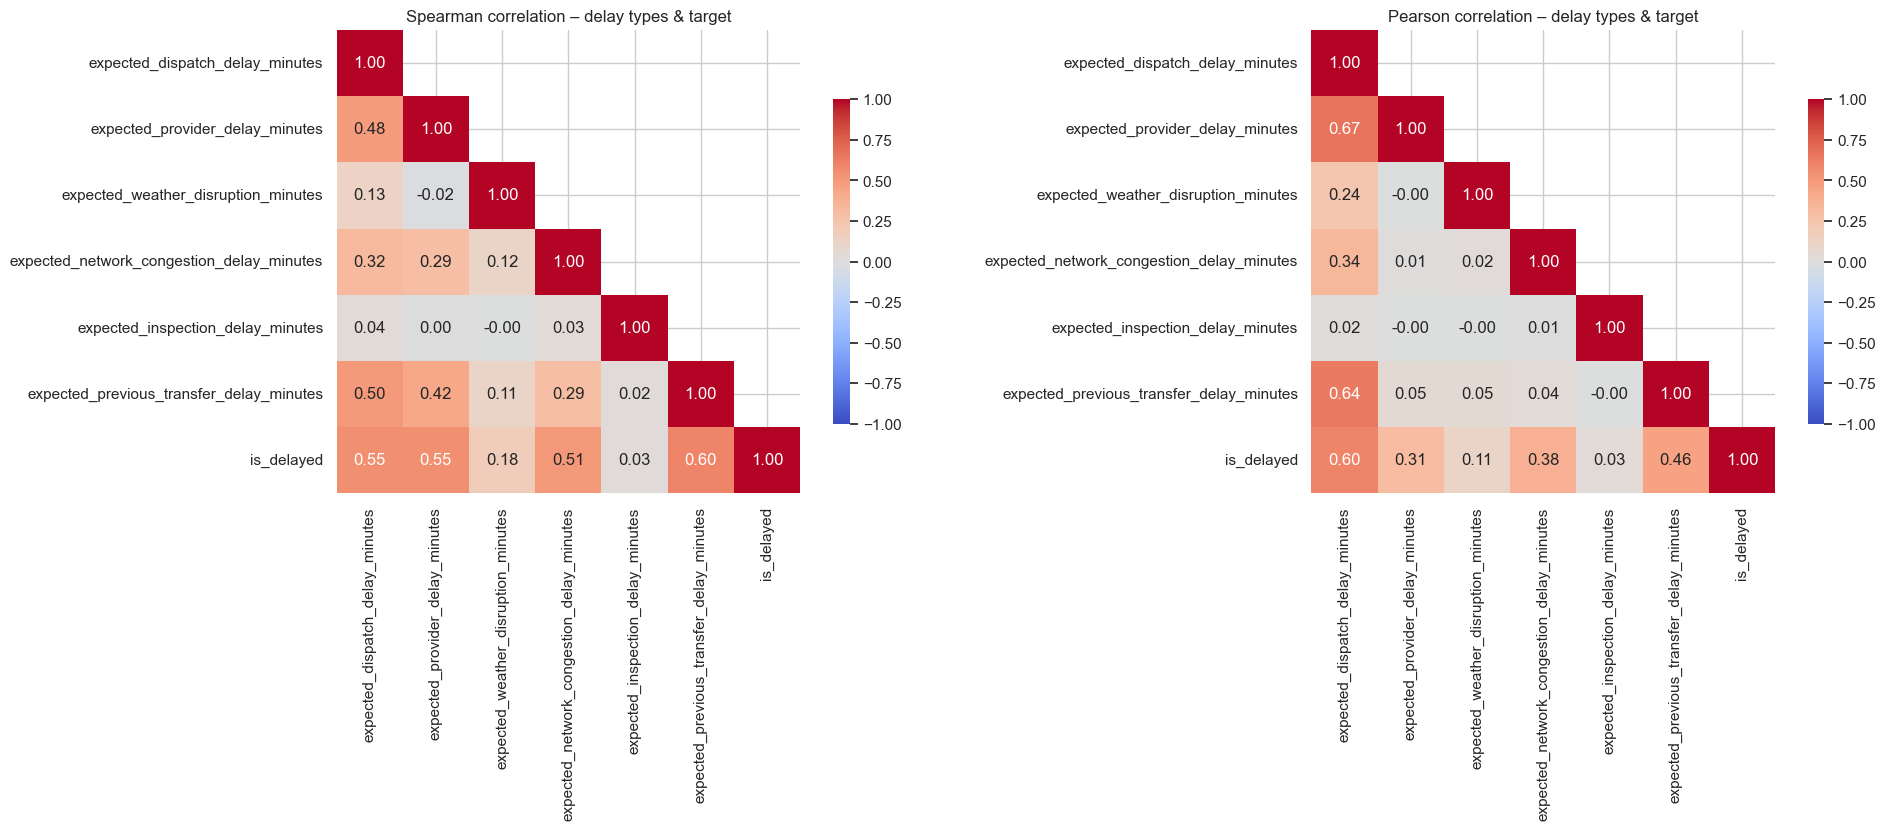

In [28]:
# Correlation between the delay types and the target (Spearman, with Pearson for reference)
corr_cols = delay_cols + [TARGET]

spearman_corr = df[corr_cols].corr(method="spearman")
pearson_corr = df[corr_cols].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, (corr, name) in zip(axes, [(spearman_corr, "Spearman"), (pearson_corr, "Pearson")]):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
    ax.set_title(f"{name} correlation – delay types & target")

fig.tight_layout()
plt.show()

### Answer 5

**There are moderate – but not extreme – correlations between the delay types, and several of them correlate well with the target.**

- **With the target (Spearman):** `expected_previous_transfer_delay_minutes` (0.60), `expected_dispatch_delay_minutes` (0.55), `expected_provider_delay_minutes` (0.55) and `expected_network_congestion_delay_minutes` (0.51) are the strongest. `expected_weather_disruption_minutes` (0.18) is weak and `expected_inspection_delay_minutes` (0.03) is essentially unrelated.
- **Between delay types:** the highest pairings are dispatch ↔ previous-transfer (0.50), dispatch ↔ provider (0.48) and provider ↔ previous-transfer (0.42). These are moderate, meaning the delay sources move together somewhat (a bad transfer tends to be late on several axes at once) but **none is strong enough (≥ 0.8) to call two columns redundant**, so we would not drop any of them purely for collinearity.
- Pearson and Spearman tell the same story; Pearson is inflated for `expected_dispatch_delay_minutes` because of its extreme tail, which is exactly why the rank-based Spearman is the safer read here.

`expected_inspection_delay_minutes` stands out as a near-useless feature (flagged again in Q6).

### Q5b – Feature-to-feature scatter plot matrix (pair plot)

To complement the correlation heatmap we plot a **scatter plot matrix of all six expected-delay features**. Each off-diagonal scatter shows the joint distribution of two features coloured by `is_delayed`; the diagonal shows the per-class KDE. Because every delay column is zero-inflated and right-skewed, we apply a **log1p transform** so that the bulk of the data (0–60 min) spreads out instead of collapsing onto the origin. Axis tick labels are kept in real minutes for readability. A random sample of 3,000 rows is used for speed.


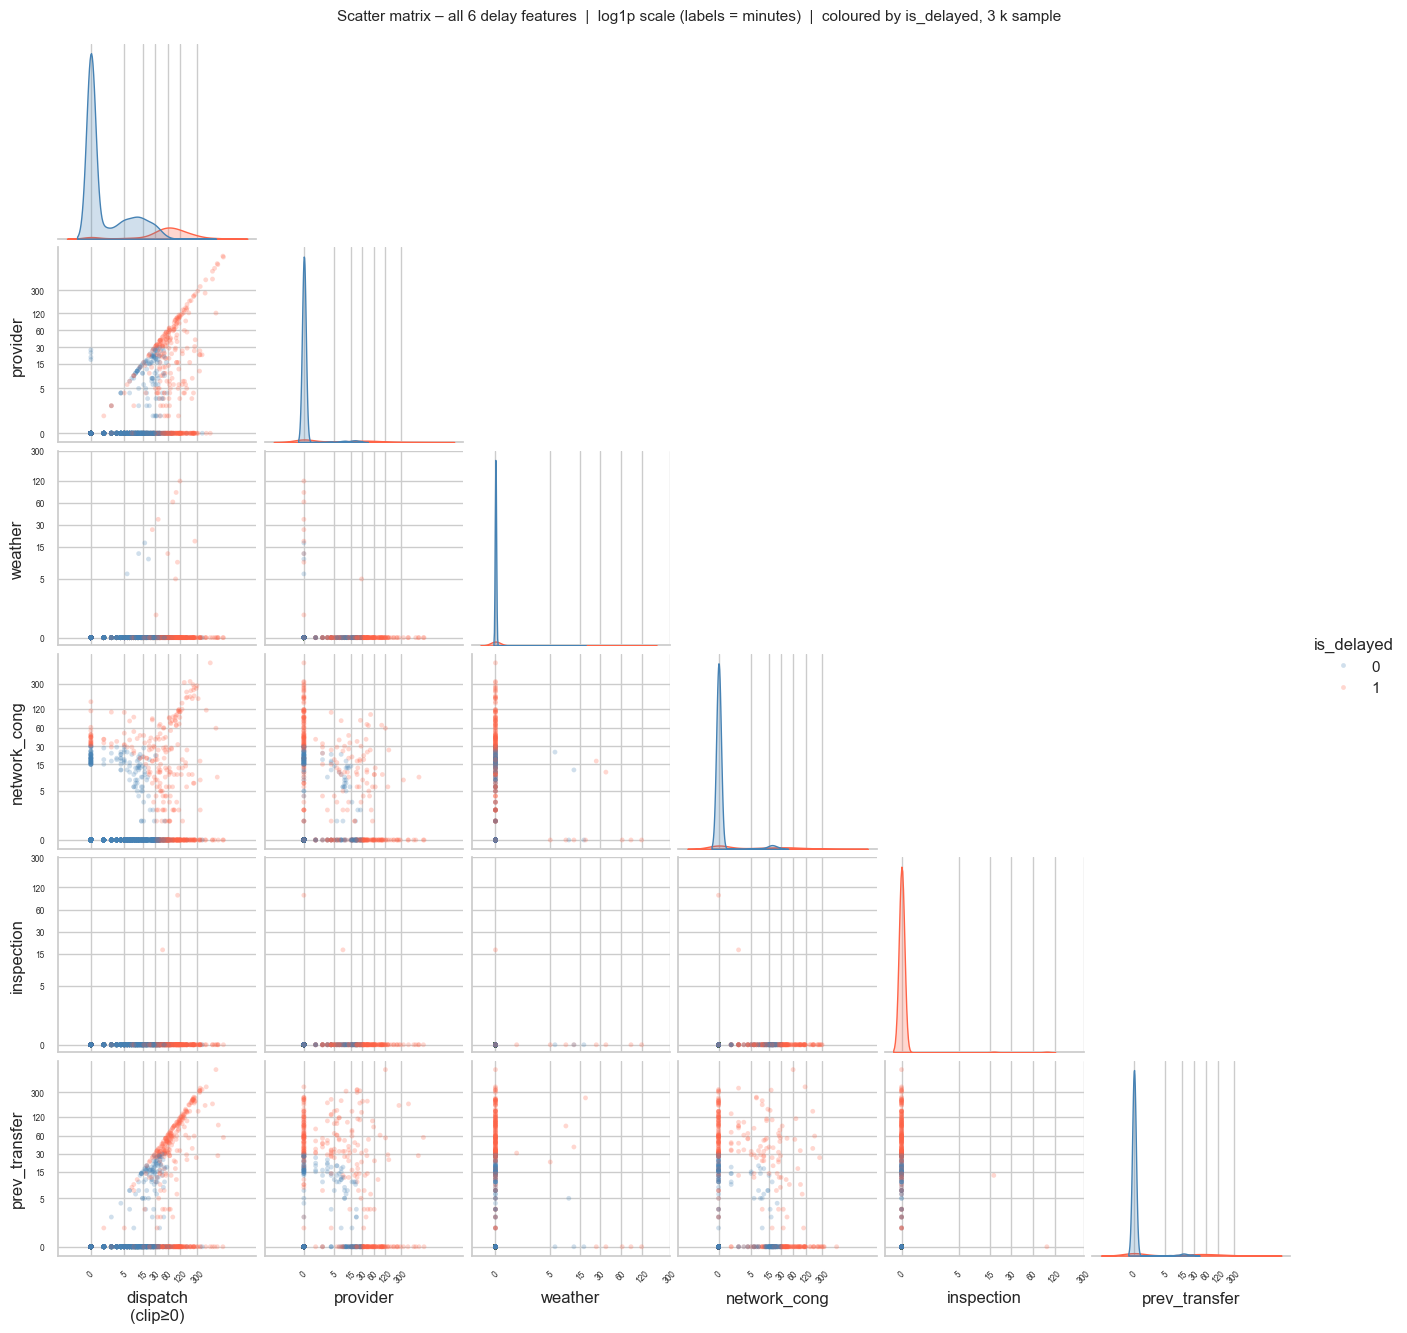

In [32]:

# Scatter plot matrix of ALL six delay features, coloured by target.
#
# All delay columns are zero-inflated with a heavy right tail, so a linear
# scale collapses most points onto (0, 0).  log1p transform maps 0 → 0,
# spreads the informative small-delay region, and compresses extreme outliers.
# expected_dispatch_delay_minutes has a tiny negative range (min ≈ -22 min);
# clipped to 0 before transforming (noted in the axis label).
# Ticks placed at real minute thresholds so the axes are human-readable.

pairplot_cols = [
    "expected_dispatch_delay_minutes",
    "expected_provider_delay_minutes",
    "expected_weather_disruption_minutes",
    "expected_network_congestion_delay_minutes",
    "expected_inspection_delay_minutes",
    "expected_previous_transfer_delay_minutes",
]
short_names = [
    "dispatch\n(clip≥0)",
    "provider",
    "weather",
    "network_cong",
    "inspection",
    "prev_transfer",
]

sample_pp = df[pairplot_cols + [TARGET]].sample(3000, random_state=RANDOM_STATE).copy()

plot_data = pd.DataFrame(
    {short: np.log1p(sample_pp[col].clip(lower=0))
     for col, short in zip(pairplot_cols, short_names)},
)
plot_data[TARGET] = sample_pp[TARGET].values

# Readable tick positions in log1p space
ref_minutes = [0, 5, 15, 30, 60, 120, 300]
tick_vals   = np.log1p(ref_minutes)
tick_labels = [str(m) for m in ref_minutes]

g = sns.pairplot(
    plot_data,
    hue=TARGET,
    palette={0: "steelblue", 1: "tomato"},
    plot_kws={"alpha": 0.25, "s": 12, "linewidth": 0},
    diag_kind="kde",
    corner=True,
    height=2.2,
    aspect=1,
)

for ax in g.axes.flatten():
    if ax is None:
        continue
    ax.set_xticks(tick_vals)
    ax.set_xticklabels(tick_labels, fontsize=6, rotation=45)
    ax.set_yticks(tick_vals)
    ax.set_yticklabels(tick_labels, fontsize=6)

g.figure.suptitle(
    "Scatter matrix – all 6 delay features  |  log1p scale (labels = minutes)"
    "  |  coloured by is_delayed, 3 k sample",
    y=1.01,
    fontsize=11,
)
plt.show()


### Q6 – Do any anonymous features look influential on the target?

We treat two groups of features as "anonymous" — their real-world meaning is hidden or encoded as opaque IDs:

1. **Numeric `internal_*` features** — five columns whose semantics are unknown. We compute the Spearman correlation with `is_delayed` and show the per-class distribution via boxplots.
2. **Categorical ID features** — `source_facility`, `destination_facility`, `source_region`, `destination_region`. These are encoded as opaque string codes with no disclosed geography or hierarchy. We compute the delay rate per category and show the top & bottom 10 to reveal whether specific IDs are systematically high- or low-risk.


Spearman correlation of internal_* features with is_delayed:
internal_timestamp_a          0.241
internal_timestamp_b          0.159
internal_metric_a             0.145
internal_metric_b             0.063
internal_operational_score    0.000
Name: is_delayed, dtype: float64


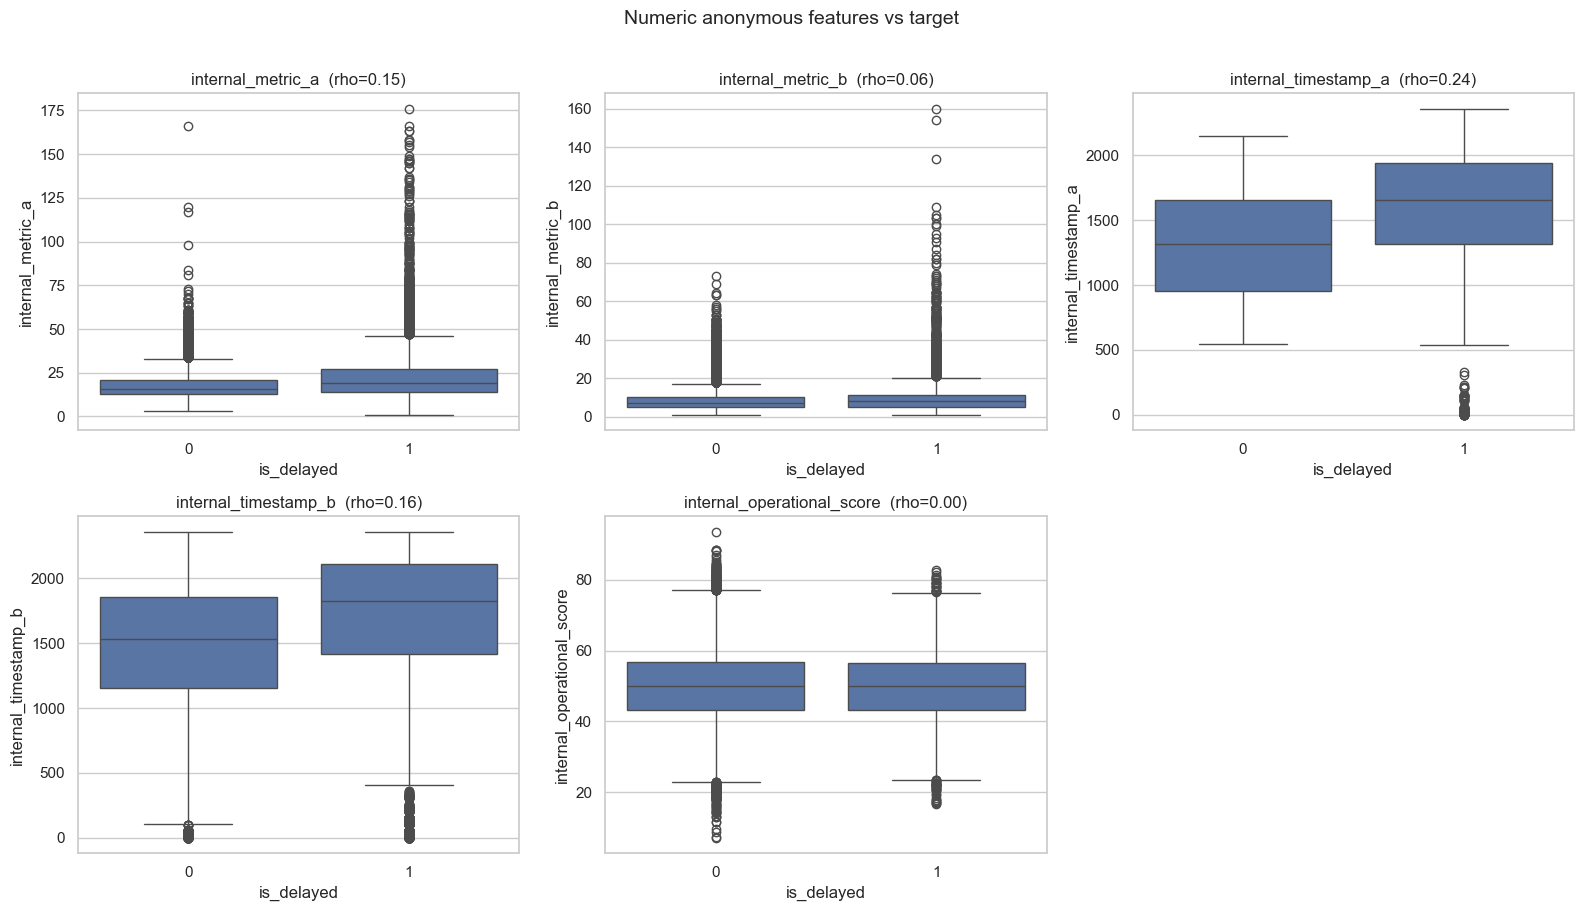

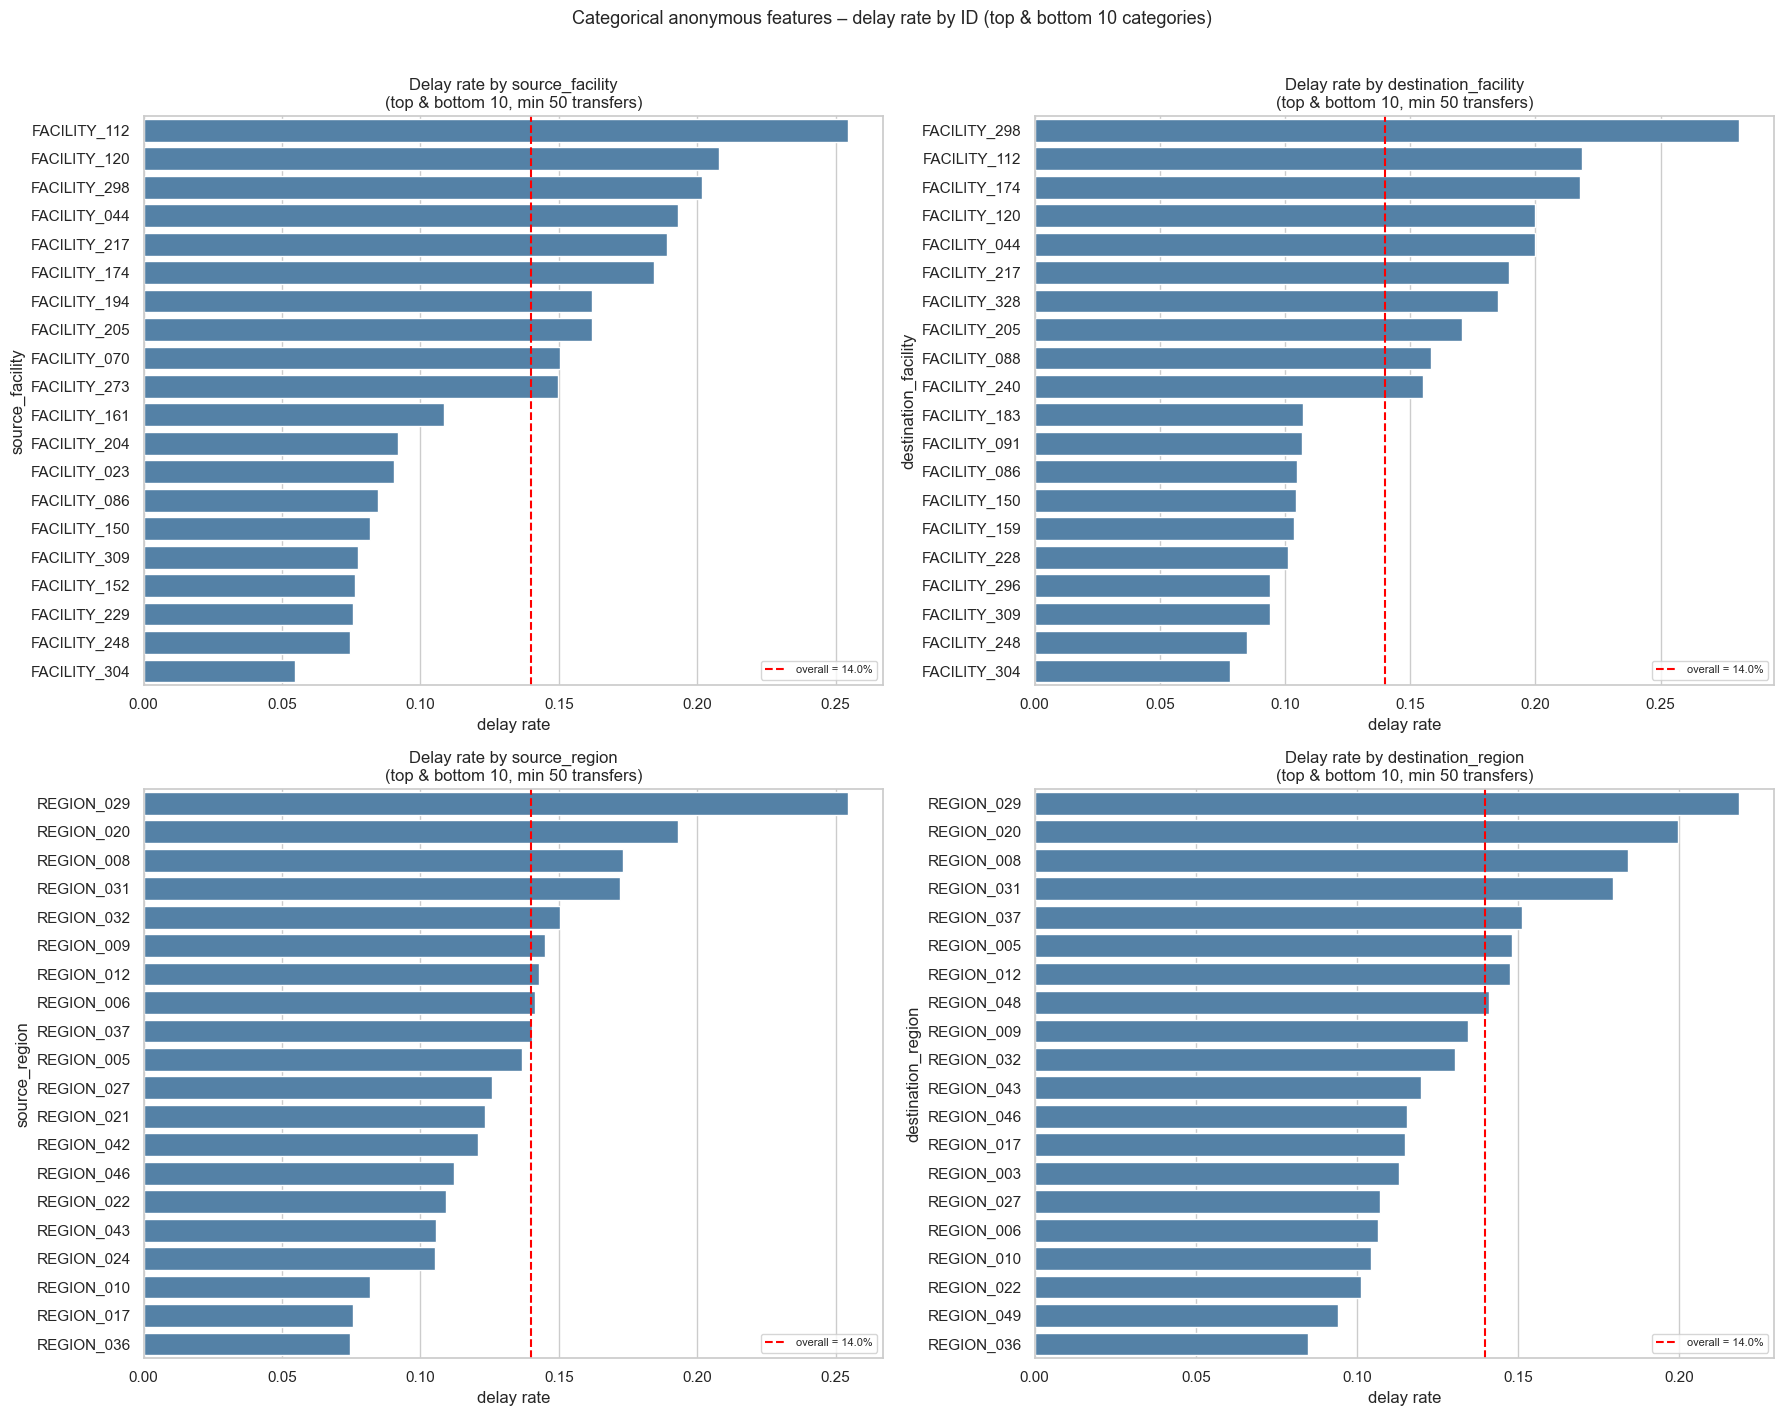


Delay-rate spread per categorical anonymous feature:
  source_facility                 min=5.5%  max=25.4%  n_categories=40
  destination_facility            min=7.8%  max=28.1%  n_categories=40
  source_region                   min=7.5%  max=25.4%  n_categories=24
  destination_region              min=8.5%  max=21.9%  n_categories=24


In [33]:

# ── Part A: Numeric internal_* features ──────────────────────────────────────
anon_corr = (df[anon_cols + [TARGET]].corr(method="spearman")[TARGET]
             .drop(TARGET).sort_values(key=np.abs, ascending=False))
print("Spearman correlation of internal_* features with is_delayed:")
print(anon_corr.round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, anon_cols):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(f"{col}  (rho={anon_corr[col]:.2f})")
    ax.set_xlabel("is_delayed")
for ax in axes[len(anon_cols):]:
    ax.set_visible(False)
fig.suptitle("Numeric anonymous features vs target", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

# ── Part B: Categorical anonymous ID features (facilities & regions) ──────────
# source_facility, destination_facility, source_region, destination_region are
# all encoded as opaque IDs with no disclosed meaning — making them anonymous.
# We show the delay rate for the top & bottom 10 categories (min 50 transfers).
cat_anon_cols = [
    "source_facility",
    "destination_facility",
    "source_region",
    "destination_region",
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat_anon_cols):
    rate = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    rate = rate[rate["n"] >= 50].sort_values("delay_rate", ascending=False)
    extremes = pd.concat([rate.head(10), rate.tail(10)]).drop_duplicates()
    sns.barplot(data=extremes.reset_index(), y=col, x="delay_rate",
                color="steelblue", ax=ax)
    ax.axvline(overall_rate, color="red", linestyle="--",
               label=f"overall = {overall_rate:.1%}")
    ax.set_title(f"Delay rate by {col}\n(top & bottom 10, min 50 transfers)")
    ax.set_xlabel("delay rate")
    ax.legend(fontsize=8)

fig.suptitle(
    "Categorical anonymous features – delay rate by ID (top & bottom 10 categories)",
    y=1.01, fontsize=13,
)
fig.tight_layout()
plt.show()

# Spread summary for all categorical anonymous features
print("\nDelay-rate spread per categorical anonymous feature:")
for col in cat_anon_cols:
    rate = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    rate = rate[rate["n"] >= 50]
    print(f"  {col:30s}  min={rate['delay_rate'].min():.1%}  "
          f"max={rate['delay_rate'].max():.1%}  "
          f"n_categories={len(rate)}")


### Answer 6

**Numeric `internal_*` features:**
- `internal_timestamp_a` (ρ = 0.24) and `internal_timestamp_b` (ρ = 0.16) are the strongest anonymous predictors; the boxplots show clearly higher values for delayed transfers. Combined with their 0–2359 range, they most likely encode *actual* dispatch/arrival clock times, which naturally relate to lateness.
- `internal_metric_a` (ρ = 0.14) carries a mild signal; `internal_metric_b` (ρ = 0.06) is weak.
- `internal_operational_score` has ρ ≈ **0.00** and **identical distributions** in both classes – despite being the only nicely Gaussian feature, it looks like uninformative noise.

**Categorical ID features (facilities & regions):**
- **Facilities:** `source_facility` and `destination_facility` show substantial delay-rate variation across IDs (spread comparable to the region features). Certain facility codes are systematically high-risk, making them useful categorical predictors despite their opaque names.
- **Regions:** `source_region` and `destination_region` were examined in Q1 and show a wide spread (~7–25% delay rate). The same pattern is visible here: a handful of region IDs (`REGION_029`, etc.) are clear hotspots on both origin and destination sides.

All four categorical ID features carry real signal and should be encoded (e.g. target-encoding or leave-one-out encoding given the many categories) in the modelling phase.


### Q7: Which features look irrelevant / low-value for prediction?

To answer the last exploration question ("are there features that look irrelevant or with very low contribution?"), we rank **all numeric features** by the absolute Spearman correlation with the target. This gives a single comparable view of strong vs. weak predictors.

TODO: Add our conclusions from the previous questions into this one, also have more explanations other then Spearman for correlation.

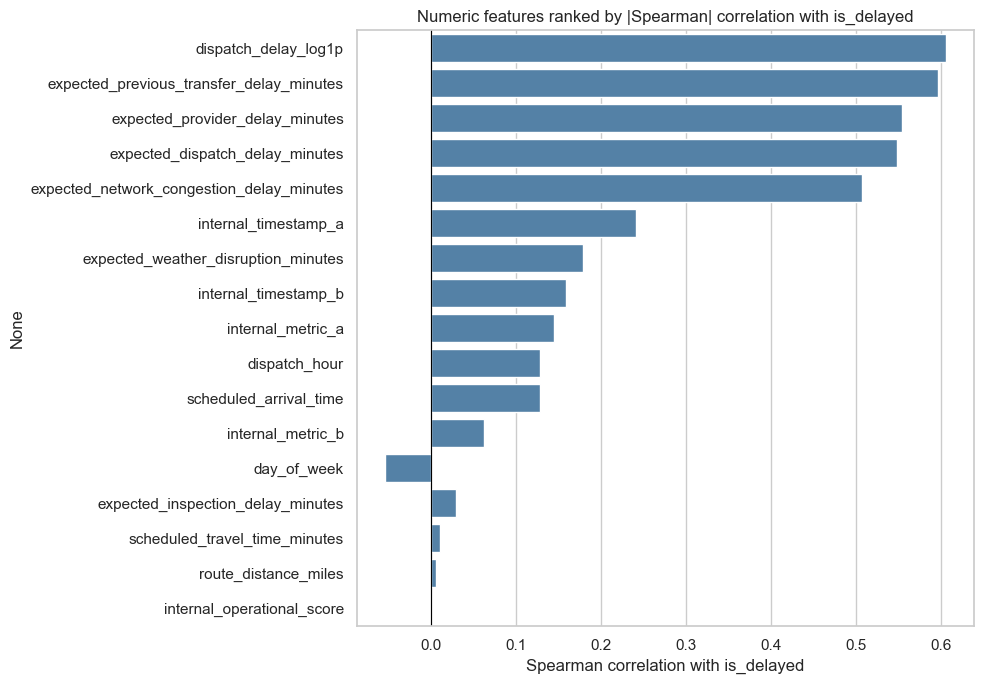

dispatch_delay_log1p                         0.606
expected_previous_transfer_delay_minutes     0.596
expected_provider_delay_minutes              0.555
expected_dispatch_delay_minutes              0.548
expected_network_congestion_delay_minutes    0.507
internal_timestamp_a                         0.241
expected_weather_disruption_minutes          0.179
internal_timestamp_b                         0.159
internal_metric_a                            0.145
dispatch_hour                                0.128
scheduled_arrival_time                       0.128
internal_metric_b                            0.063
day_of_week                                 -0.054
expected_inspection_delay_minutes            0.030
scheduled_travel_time_minutes                0.010
route_distance_miles                         0.007
internal_operational_score                   0.000
Name: is_delayed, dtype: float64

In [34]:
# Rank every numeric feature by |Spearman correlation| with the target
numeric_features = (df.select_dtypes(include=[np.number])
                      .columns.drop([TARGET, "scheduled_dispatch_time"]))
feature_strength = (df[list(numeric_features) + [TARGET]].corr(method="spearman")[TARGET]
                    .drop(TARGET))
feature_strength = feature_strength.reindex(feature_strength.abs()
                                            .sort_values(ascending=False).index)

plt.figure(figsize=(10, 7))
sns.barplot(x=feature_strength.values, y=feature_strength.index, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Numeric features ranked by |Spearman| correlation with is_delayed")
plt.xlabel("Spearman correlation with is_delayed")
plt.tight_layout()
plt.show()

feature_strength.round(3)

### Answer 7

TODO

### Conclusions

- **Size & target.** The training set has **51,056 transfers and 23 columns**. The target `is_delayed` is binary and **imbalanced**: only ~**14%** of transfers are delayed by more than 30 minutes. AUC (the project metric) is a sensible choice given this imbalance.
- **Column roles.** We can group the columns into: *scheduling/time* fields (`scheduled_dispatch_time`, `scheduled_arrival_time`, `day_of_week`, `operation_date`), *route* fields (`scheduled_travel_time_minutes`, `route_distance_miles`), six *expected delay* fields, five anonymous *internal_* fields, and *categorical* identifiers (regions, facilities, provider). The time fields are stored as integers in `HHMM` format (e.g. `830` = 08:30).
- **Missing values.** Nine columns contain missing values, the largest being `internal_metric_a` (16.3%), `expected_inspection_delay_minutes` (12.0%) and `internal_metric_b` (11.3%). No column is missing more than ~16%, so none should be dropped purely for missingness; we will impute them in the preprocessing phase.
- **Skew & outliers.** The six expected-delay columns are strongly **zero-inflated and right-skewed** (75th percentile is 0 for most of them, but maxima reach ~1,000–2,000 minutes). `expected_dispatch_delay_minutes` ranges from −22 (early dispatch) to 2,120 minutes. `route_distance_miles` has a clear outlier tail (max 14,342 vs. a 75th percentile of ~1,498). `internal_operational_score` looks roughly symmetric around 50. These point to heavy-tailed distributions that we examine next.

## Exploration Summary

Main takeaways from Part 1, to carry into preprocessing and modelling:

- **Target.** Binary and imbalanced (~14% delayed); AUC is the right metric.
- **Strongest predictors.** The expected-delay sources – `expected_previous_transfer_delay_minutes`, `expected_provider_delay_minutes`, `expected_dispatch_delay_minutes`, `expected_network_congestion_delay_minutes` – plus the engineered `dispatch_hour` and the anonymous `internal_timestamp_a/b`.
- **Departure → arrival propagation.** Departure delays above ~30 minutes translate into a very high probability of a significant arrival delay (60% at 30–60 min, 98% above 60 min).
- **Categorical signal.** Both `logistics_provider` and the region fields show large delay-rate differences; provider text needs whitespace normalisation.
- **Weak / noise features.** `route_distance_miles`, `scheduled_travel_time_minutes`, `expected_inspection_delay_minutes` and `internal_operational_score` show almost no marginal link to the target.
- **Preprocessing to-do (Part 2).** Handle missing values (up to ~16%), the heavy right tails / outliers in the delay columns, normalisation/scaling, categorical encoding, and re-check the weak features with model-based importance before dropping.

*Helper columns created during exploration (`dispatch_hour`, `dispatch_delay_bin`, `distance_bin`) are kept only for analysis; the formal feature engineering is done in Part 2.*

In [ ]:
# The provider plot shows some codes twice -> check for inconsistent text (spaces / casing)
provider_counts = df["logistics_provider"].value_counts()
print(provider_counts)
print("\nRaw unique values (repr to expose whitespace/case):")
print([repr(v) for v in df["logistics_provider"].unique()])